In [2]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from matplotlib.cm import get_cmap

cmap = get_cmap("viridis")

p_list = ["p_05", "p_1", "p_5"]
a_list = ["a_1", "a_5", "a_10"]
base_path = Path(r'C:\Users\korol\OneDrive\Pulpit\Master\CUP - remove asymmetric, remove orbits, counting changes\test_graphs')
base_plots = Path(r'C:\Users\korol\OneDrive\Pulpit\Master\CUP - remove asymmetric, remove orbits, counting changes\plots')
sns.set_theme(style="whitegrid")

C:\Users\korol\AppData\Local\Temp\ipykernel_21556\1311664302.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("viridis")


What results do I need?
RANDOM GRAPHS
My algorithm works best 
1. the average number of vertices in the queue: how many vertices is being processed, compared to n

In [3]:
up_funcs = ["cor", "cas","cup"]
JSON_COLUMNS = ["n", "m", "k", "T_old", "T_up",  "T_delta", "q_lens", "q_len_average", 
                "sym_old", "sym_up", "unique_old", "unique_up",
                "v_changed", "W", "q_avg_real", "S", "changed_edges", "coloring"]

def load_json(x):
    try:
        return json.loads(x)
    except:
        return x
    
def unpack_file(f_name, update_function):
    path = base_path /  f"result_{f_name}_{update_function}.csv"

    df = pd.read_csv(
        path,
        converters={col: load_json for col in JSON_COLUMNS}
    )
    df = df.sort_values("n")
    return df

def df_categorical(result_dict, col):
    n_list = list(result_dict["cup"]["n"])

    df_wide = pd.DataFrame({
        "graph_id": range(len(n_list)),
        "n": n_list,
        "cup": list(result_dict["cup"][col]),
        "cas": list(result_dict["cas"][col]),
        "cor": list(result_dict["cor"][col]),
    })

    df_long = df_wide.melt(
        id_vars=["graph_id", "n"],
        var_name="algorithm",
        value_name=col
    )
    
    return df_long

### Trees
1. W/n vs n
2. * W/n vs size of a smaller component
3. v_changed 

In [17]:
results_trees = {up_func: unpack_file("trees_remove_edge", up_func) for up_func in ["cup", "cas", "cor"]}

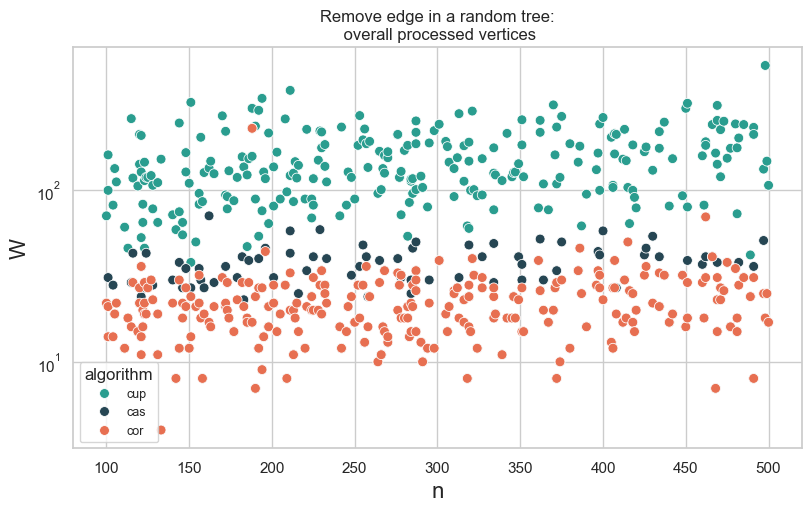

In [47]:
# Trees - W
results = {up_func: unpack_file("trees_remove_edge", up_func) for up_func in ["cup", "cas", "cor"]}
sns.set_theme(context="notebook", style="whitegrid")
palette = {
    "cas": "#264653",  # deep blue-green
    "cor": "#E76F51",  # coral
    "cup": "#2A9D8F"   # teal
}

df_long = df_categorical(results, "W")

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    sharey=True,
    figsize=(8, 5),
    constrained_layout=True
)

sns.scatterplot(data=df_long, 
                x="n", 
                y="W", 
                hue="algorithm", 
                palette=palette, 
                ax=ax,
                s=50)
ax.set_title(f"Remove edge in a random tree:\n overall processed vertices")
ax.set_xlabel("n", fontsize=16)
ax.set_ylabel("W", fontsize=16)

plt.yscale('log')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="algorithm", fontsize=9)
plt.savefig(base_plots / "trees" / "W.png", dpi=300)
plt.show()



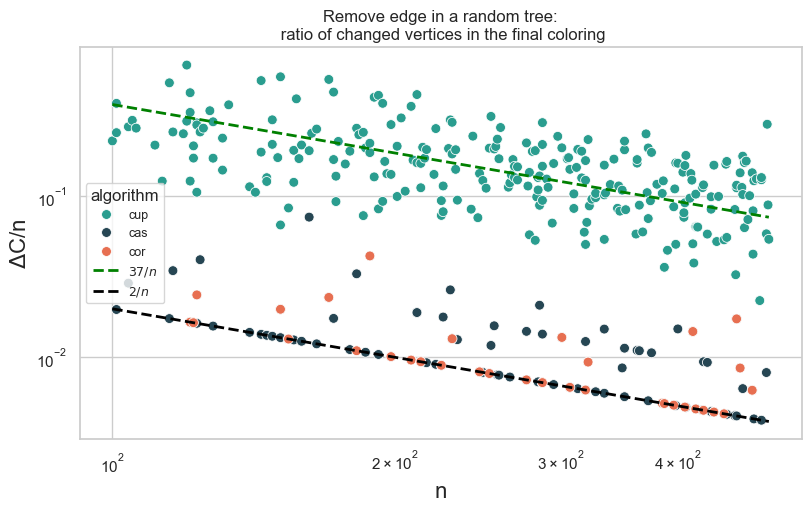

In [46]:
# Trees - v changed
results = {up_func: unpack_file("trees_remove_edge", up_func) for up_func in ["cup", "cas", "cor"]}
sns.set_theme(context="notebook", style="whitegrid")
palette = {
    "cas": "#264653",  # deep blue-green
    "cor": "#E76F51",  # coral
    "cup": "#2A9D8F"   # teal
}


df_long = df_categorical(results, "v_changed")
df_long["v_changed_norm"] = df_long["v_changed"] /df_long["n"]

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    sharey=True,
    figsize=(8, 5),
    constrained_layout=True
)

sns.scatterplot(data=df_long, 
                x="n", 
                y="v_changed_norm", 
                hue="algorithm", 
                palette=palette, 
                ax=ax,
                s=50)

sub = df_long[df_long["algorithm"] == "cup"].copy()
# robust estimate of c for y ~ c/n
c = np.exp(np.median(np.log(sub["v_changed_norm"] * sub["n"])))
n_vals = np.linspace(df_long["n"].min(), df_long["n"].max(), 500)
ax.plot(n_vals, c/n_vals, "--", color="green", lw=2, label=rf"${c:.2g}/n$")
ax.plot(n_vals, 2/n_vals, "--", color="black", lw=2, label=rf"${2}/n$")

ax.legend(title="algorithm", fontsize=9)
ax.set_title(f"Remove edge in a random tree:\n ratio of changed vertices in the final coloring")
ax.set_xlabel("n", fontsize=16)
ax.set_ylabel(r"$\Delta$C/n", fontsize=16)
plt.yscale('log')
plt.xscale('log')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="algorithm", fontsize=9)
plt.savefig(base_plots / "trees" / "v_changed.png", dpi=300)
plt.show()


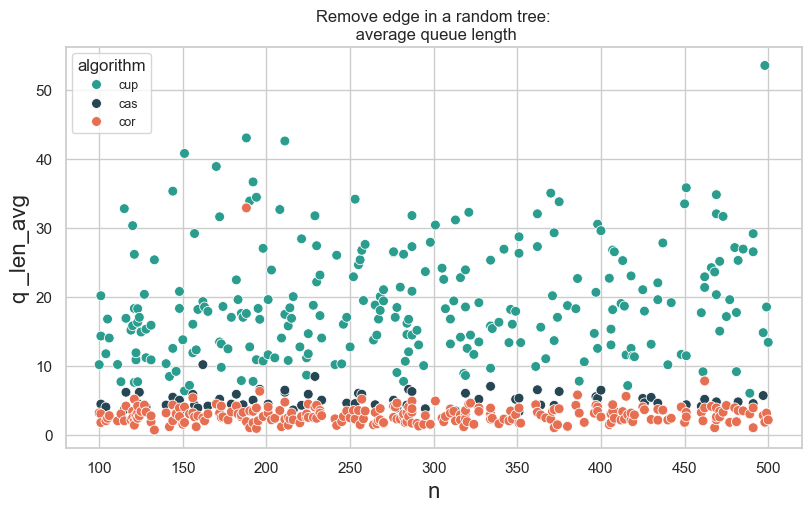

In [45]:
# average q len (real)
results = {up_func: unpack_file("trees_remove_edge", up_func) for up_func in ["cup", "cas", "cor"]}
sns.set_theme(context="notebook", style="whitegrid")
palette = {
    "cas": "#264653",  # deep blue-green
    "cor": "#E76F51",  # coral
    "cup": "#2A9D8F"   # teal
}


df_long = df_categorical(results, "q_len_average")


fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    sharey=True,
    figsize=(8, 5),
    constrained_layout=True
)

sns.scatterplot(data=df_long, 
                x="n", 
                y="q_len_average", 
                hue="algorithm", 
                palette=palette, 
                ax=ax,
                s=50)

ax.set_title(f"Remove edge in a random tree:\n average queue length")
ax.set_xlabel("n", fontsize=16)
ax.set_ylabel("q _len_avg", fontsize=16)
#plt.yscale('log')


handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="algorithm", fontsize=9)
plt.savefig(base_plots / "trees" / "q_len_avg.png", dpi=300)

plt.show()

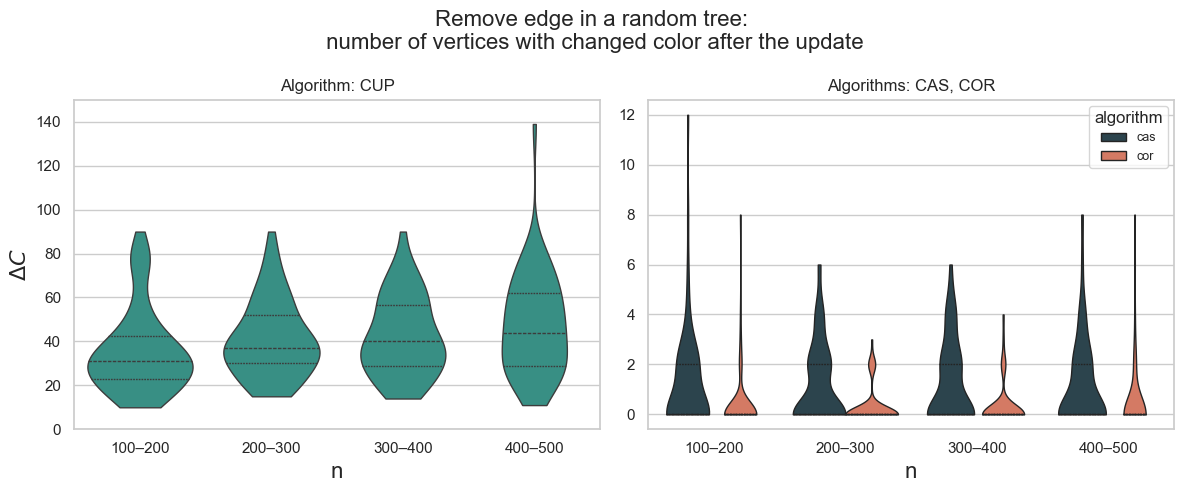

In [49]:
# Box/violin - v_changed

results = {up_func: unpack_file("trees_remove_edge", up_func) for up_func in ["cup", "cas", "cor"]}
sns.set_theme(context="notebook", style="whitegrid")
palette = {
    "cas": "#264653",  # deep blue-green
    "cor": "#E76F51",  # coral
    "cup": "#2A9D8F"   # teal
}

df = df_categorical(results, "v_changed")


df["v_changed_norm"] = df["v_changed"]

# Bin n (100–500 into 4 bins; adjust as you like)
bins = [100, 200, 300, 400, 500]
labels = ["100–200", "200–300", "300–400", "400–500"]
df["n_bin"] = pd.cut(df["n"], bins=bins, labels=labels, include_lowest=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# (a) CUP only
df_cup = df[df["algorithm"] == "cup"]
sns.violinplot(
    data=df_cup, 
    x="n_bin", 
    y="v_changed",
    hue="algorithm",
    hue_order=["cup"],
    palette={"cup": palette["cup"]},
    cut=0, 
    inner="quartile", 
    linewidth=1, 
    ax=axes[0]
)
axes[0].set_title("Algorithm: CUP")
axes[0].set_xlabel("n", fontsize=16)
axes[0].set_ylabel(r"$\Delta C$", fontsize=16)
axes[0].set_ylim(0, 150)
axes[0].legend_.remove()

# (b) CAS + COR
df_pruned = df[df["algorithm"].isin(["cas","cor"])]
sns.violinplot(
    data=df_pruned, 
    x="n_bin", 
    y="v_changed", 
    hue="algorithm",
    hue_order=["cas", "cor"],
    palette={"cas": palette["cas"], "cor": palette["cor"]},
    cut=0, 
    inner="quartile", 
    linewidth=1, 
    dodge=True, 
    ax=axes[1]
)
axes[1].set_title("Algorithms: CAS, COR")
axes[1].set_xlabel("n", fontsize=16)
axes[1].set_ylabel("")  # already on left
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, title="algorithm", fontsize=9, loc="upper right")

fig.suptitle(f"Remove edge in a random tree:\n number of vertices with changed color after the update", fontsize=16)
plt.tight_layout()
plt.savefig(base_plots / "trees" / "delta_C_violin.png", dpi=300)
plt.show()

In [26]:
# Summary table: delta T

# n (int), method (str: "CUP"/"CAS"/"COR"), delta_C (int), T_old (int), T_upd (int)
# df = pd.read_csv("trees_results.csv")
results = {up_func: unpack_file("trees_remove_edge", up_func) for up_func in ["cup", "cas", "cor"]}
dfC = df_categorical(results, "v_changed")
dfT = df_categorical(results, "T_delta")

df = dfC.merge(dfT, on=["graph_id","n","algorithm"], how="inner", validate="one_to_one")

df["c_delta"] = df["v_changed"]

order = ["cup", "cas", "cor"]
df["algorithm"] = pd.Categorical(df["algorithm"], categories=order, ordered=True)

def iqr(x: pd.Series) -> float:
    return x.quantile(0.75) - x.quantile(0.25)

summary = (
    df.groupby("algorithm")
    .agg(
        runs=("n", "size"),

        c_delta_median=("c_delta", "median"),
        c_delta_IQR=("c_delta", iqr),

        T_delta_median=("T_delta", "median"),
        T_delta_IQR=("T_delta", iqr),

        p_T_delta_nonzero=("T_delta", lambda s: (s != 0).mean()),
    )
    .reset_index()
    .sort_values("algorithm")
)
#summary = summary.reindex([2,0,1])
print(summary)

  algorithm  runs  c_delta_median  c_delta_IQR  T_delta_median  T_delta_IQR  \
0       cup   250            37.0         26.0             0.0          0.0   
1       cas   250             0.0          2.0             2.0          3.0   
2       cor   250             0.0          0.0             3.0          1.0   

   p_T_delta_nonzero  
0              0.036  
1              0.604  
2              0.868  


C:\Users\korol\AppData\Local\Temp\ipykernel_23148\1208221796.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("algorithm")


In [27]:
order = ["cup", "cas", "cor"]
df = df.copy()
df["algorithm"] = pd.Categorical(df["algorithm"], categories=order, ordered=True)

# Example: describe() for c_delta, plus p(c_delta > 0)
desc_c = (df.groupby("algorithm")["c_delta"]
            .describe(percentiles=[0.25, 0.5, 0.75])
            .rename(columns={"50%": "median"}))

p_pos_c = (df.groupby("algorithm")["c_delta"]
             .apply(lambda s: (s > 0).mean())
             .rename("p(c_delta>0)"))

tab_c = desc_c.join(p_pos_c).loc[order]
print(tab_c)

# Same idea for T_delta, plus p(T_delta != 0)
desc_T = (df.groupby("algorithm")["T_delta"]
            .describe(percentiles=[0.25, 0.5, 0.75])
            .rename(columns={"50%": "median"}))

p_nonzero_T = (df.groupby("algorithm")["T_delta"]
                 .apply(lambda s: (s != 0).mean())
                 .rename("p(T_delta!=0)"))

tab_T = desc_T.join(p_nonzero_T).loc[order]
print(tab_T)

# Optional: LaTeX export
tab_c.to_latex(base_plots / "trees" / "table_c_delta_describe.tex", float_format="%.4g")
tab_T.to_latex(base_plots / "trees" / "table_T_delta_describe.tex", float_format="%.4g")

C:\Users\korol\AppData\Local\Temp\ipykernel_23148\524624048.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc_c = (df.groupby("algorithm")["c_delta"]
C:\Users\korol\AppData\Local\Temp\ipykernel_23148\524624048.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p_pos_c = (df.groupby("algorithm")["c_delta"]
C:\Users\korol\AppData\Local\Temp\ipykernel_23148\524624048.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warnin

           count    mean        std   min   25%  median   75%    max  \
algorithm                                                              
cup        250.0  41.104  19.616534  10.0  27.0    37.0  53.0  139.0   
cas        250.0   1.188   1.774613   0.0   0.0     0.0   2.0   12.0   
cor        250.0   0.380   1.120994   0.0   0.0     0.0   0.0    8.0   

           p(c_delta>0)  
algorithm                
cup               1.000  
cas               0.404  
cor               0.136  
           count   mean       std  min  25%  median  75%  max  p(T_delta!=0)
algorithm                                                                   
cup        250.0  0.028  0.188036 -1.0  0.0     0.0  0.0  1.0          0.036
cas        250.0  1.672  1.665989 -1.0  0.0     2.0  3.0  7.0          0.604
cor        250.0  2.476  1.475851 -1.0  2.0     3.0  3.0  7.0          0.868


In [28]:
# Expected: one row per graph instance
# Columns: n, sym_old, sym_up, unique_old, unique_up (counts)
# If they are already fractions, skip the "/ n" normalization below.

dfg = unpack_file("trees_remove_edge", "cor").copy()

# Normalize to fractions for comparability across n
for c in ["sym_old", "sym_up", "unique_old", "unique_up"]:
    dfg[c + "_frac"] = dfg[c] / dfg["n"]

cols = ["sym_old_frac", "sym_up_frac", "unique_old_frac", "unique_up_frac"]

# One-row dataset summary: mean ± std (you can switch to median/IQR if you prefer)
out = pd.DataFrame({
    "dataset": ["Random trees (n=100–500), remove 1 random edge"],
    "runs": [len(dfg)],
})

for c in cols:
    out[c] = [f"{dfg[c].mean():.3f} ± {dfg[c].std():.3f}"]

# Optional: also report the mean change after update
out["Δsym_frac"] = [f"{(dfg['sym_up_frac'] - dfg['sym_old_frac']).mean():.3f}"]
out["Δunique_frac"] = [f"{(dfg['unique_up_frac'] - dfg['unique_old_frac']).mean():.3f}"]

# Rename columns to nicer LaTeX-style headers
out = out.rename(columns={
    "sym_old_frac": "sym_old/n",
    "sym_up_frac": "sym_up/n",
    "unique_old_frac": "unique_old/n",
    "unique_up_frac": "unique_up/n",
})

print(out)

# Export to LaTeX
out.to_latex(base_plots / "trees" / "dataset_symmetry_summary.tex", index=False, escape=False)

                                          dataset  runs      sym_old/n  \
0  Random trees (n=100–500), remove 1 random edge   250  0.158 ± 0.037   

        sym_up/n   unique_old/n    unique_up/n Δsym_frac Δunique_frac  
0  0.157 ± 0.037  0.917 ± 0.020  0.917 ± 0.020    -0.001        0.001  


### Random graphs
I left p =0.03 bcs sth is wrong with data
1. W: all p vs alpha = 0.005, p = 0.01 vs all alpha

In [5]:
all_results = {
    "p_05": {
        "a_1": {up_func: unpack_file("rg_p_05_a_1", up_func) for up_func in ["cup", "cas", "cor"]},
        "a_5": {up_func: unpack_file("rg_p_05_a_5", up_func) for up_func in ["cup", "cas", "cor"]},
        "a_10": {up_func: unpack_file("rg_p_05_a_10", up_func) for up_func in ["cup", "cas", "cor"]},
    },
    "p_1": {
        "a_1": {up_func: unpack_file("rg_p_1_a_1", up_func) for up_func in ["cup", "cas", "cor"]},
        "a_5": {up_func: unpack_file("rg_p_1_a_5", up_func) for up_func in ["cup", "cas", "cor"]},
        "a_10": {up_func: unpack_file("rg_p_1_a_10", up_func) for up_func in ["cup", "cas", "cor"]},
    },
    "p_3": {
        "a_1": {up_func: unpack_file("rg_p_3_a_1", up_func) for up_func in ["cup", "cas", "cor"]},
        "a_5": {up_func: unpack_file("rg_p_3_a_5", up_func) for up_func in ["cup", "cas", "cor"]},
        "a_10": {up_func: unpack_file("rg_p_3_a_10", up_func) for up_func in ["cup", "cas", "cor"]},
    },
    "p_5": {
        "a_1": {up_func: unpack_file("rg_p_5_a_1", up_func) for up_func in ["cup", "cas", "cor"]},
        "a_5": {up_func: unpack_file("rg_p_5_a_5", up_func) for up_func in ["cup", "cas", "cor"]},
        "a_10": {up_func: unpack_file("rg_p_5_a_10", up_func) for up_func in ["cup", "cas", "cor"]},
    }
}

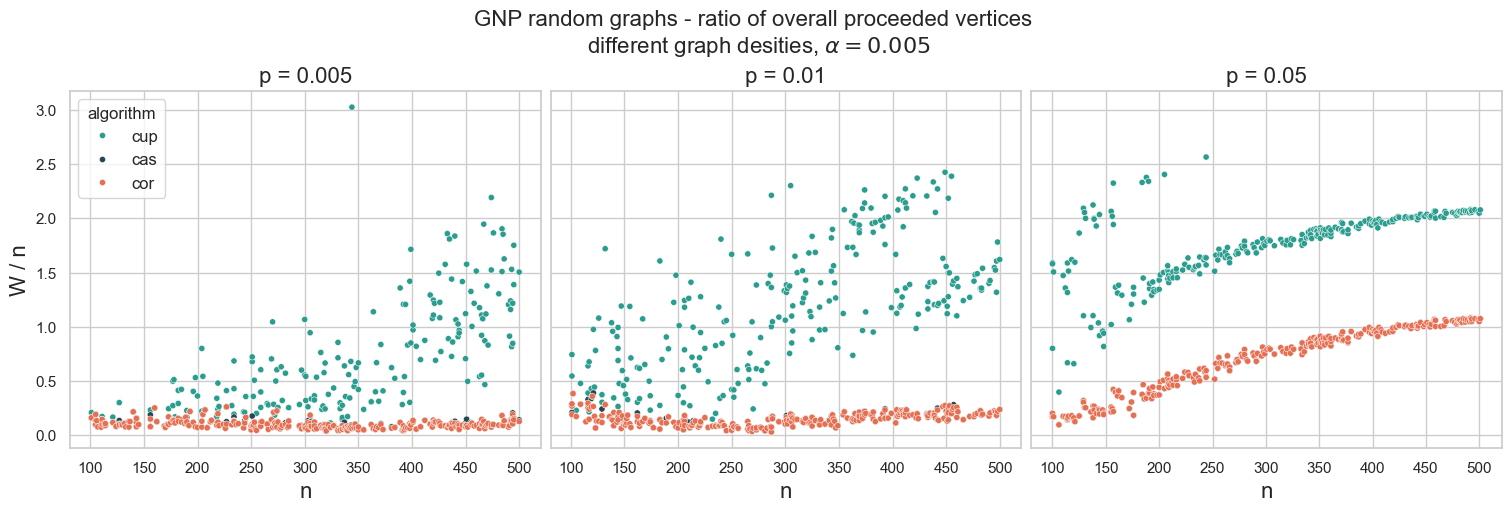

In [50]:
# all p vs alpha = 0.005
results = [all_results[p]["a_5"] for p in p_list]
sns.set_theme(context="notebook", style="whitegrid")
palette = {
    "cas": "#264653",  # deep blue-green
    "cor": "#E76F51",  # coral
    "cup": "#2A9D8F"   # teal
}


fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    sharey=True,
    figsize=(15, 5),
    constrained_layout=True
)
for k in range(3):
    ax = axes[k]
    p = [0.005, 0.01, 0.05][k]
    df_long = df_categorical(results[k], "W")
    df_long["W_norm"] = df_long["W"] /df_long["n"]
    sns.scatterplot(data=df_long, 
                    x="n", 
                    y="W_norm", 
                    hue="algorithm", 
                    palette=palette, 
                    ax=ax,
                    s=20)

    ax.set_title(f"p = {p}", fontsize=16)
    ax.set_xlabel("n", fontsize=16)
    ax.set_ylabel("W / n", fontsize=16)
    #ax.set_ylim(1,1200)
    #ax.set_yscale("log")  
    ax.legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, title="algorithm", fontsize=12)
    
fig.suptitle(f"GNP random graphs - ratio of overall proceeded vertices \n different graph desities, " + r"$\alpha = 0.005$", fontsize=16)
plt.savefig(base_plots / "random_graphs" / "W_norm_vs_p.png", dpi=300)
plt.show()


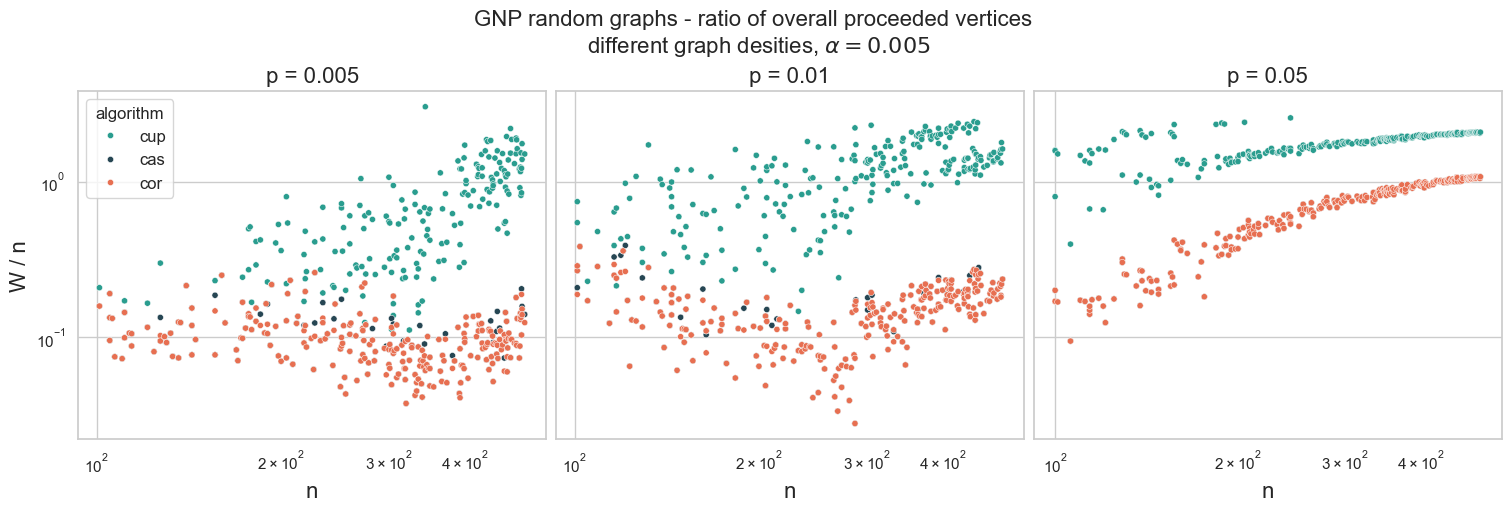

In [117]:
# W - loglog - all p vs alpha = 0.005
results = [all_results[p]["a_5"] for p in p_list]
sns.set_theme(context="notebook", style="whitegrid")
palette = {
    "cas": "#264653",  # deep blue-green
    "cor": "#E76F51",  # coral
    "cup": "#2A9D8F"   # teal
}


fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    sharey=True,
    figsize=(15, 5),
    constrained_layout=True
)
for k in range(3):
    ax = axes[k]
    p = [0.005, 0.01, 0.05][k]
    df_long = df_categorical(results[k], "W")
    df_long["W_norm"] = df_long["W"] /df_long["n"]
    sns.scatterplot(data=df_long, 
                    x="n", 
                    y="W_norm", 
                    hue="algorithm", 
                    palette=palette, 
                    ax=ax,
                    s=20)

    ax.set_title(f"p = {p}", fontsize=16)
    ax.set_xlabel("n", fontsize=16)
    ax.set_ylabel("W / n", fontsize=16)
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, title="algorithm", fontsize=12)
    
fig.suptitle(f"GNP random graphs - ratio of overall proceeded vertices \n different graph desities, " + r"$\alpha = 0.005$", fontsize=16)
#plt.savefig(base_plots / "random_graphs" / "W_norm_vs_p_log.png", dpi=300)
plt.show()

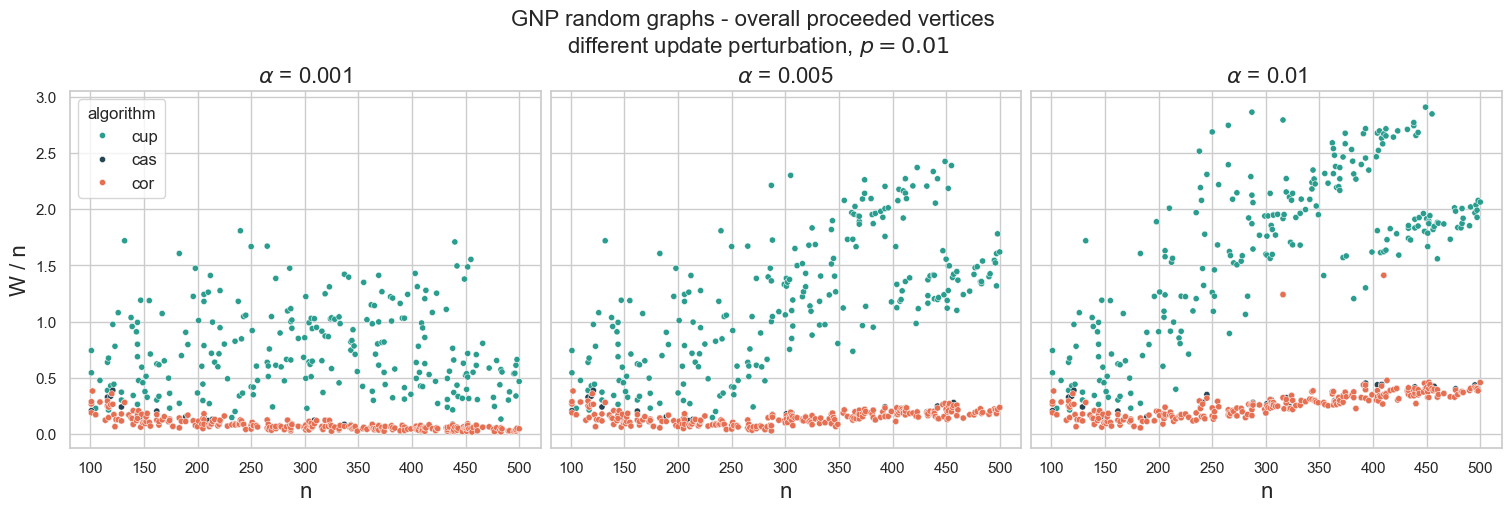

In [77]:
# all alpha vs p = 0.01
results = [all_results["p_1"][a] for a in a_list]
sns.set_theme(context="notebook", style="whitegrid")
palette = {
    "cas": "#264653",  # deep blue-green
    "cor": "#E76F51",  # coral
    "cup": "#2A9D8F"   # teal
}


fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    sharey=True,
    figsize=(15, 5),
    constrained_layout=True
)
for k in range(3):
    ax = axes[k]
    a = [0.001, 0.005, 0.01][k]
    df_long = df_categorical(results[k], "W")
    df_long["W_norm"] = df_long["W"] /df_long["n"]
    sns.scatterplot(data=df_long, 
                    x="n", 
                    y="W_norm", 
                    hue="algorithm", 
                    palette=palette, 
                    ax=ax,
                    s=20)

    ax.set_title(fr"$\alpha$ = {a}", fontsize=16)
    ax.set_xlabel("n", fontsize=16)
    ax.set_ylabel("W / n", fontsize=16)
    #ax.set_ylim(0,1200)
    #ax.set_yscale("log")  
    ax.legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, title="algorithm", fontsize=12, loc="upper left")

fig.suptitle(f"GNP random graphs - overall proceeded vertices \n different update perturbation, " + r"$p = 0.01$", fontsize=16)
plt.savefig(base_plots / "random_graphs" / "W_norm_vs_alpha.png", dpi=300)
plt.show()

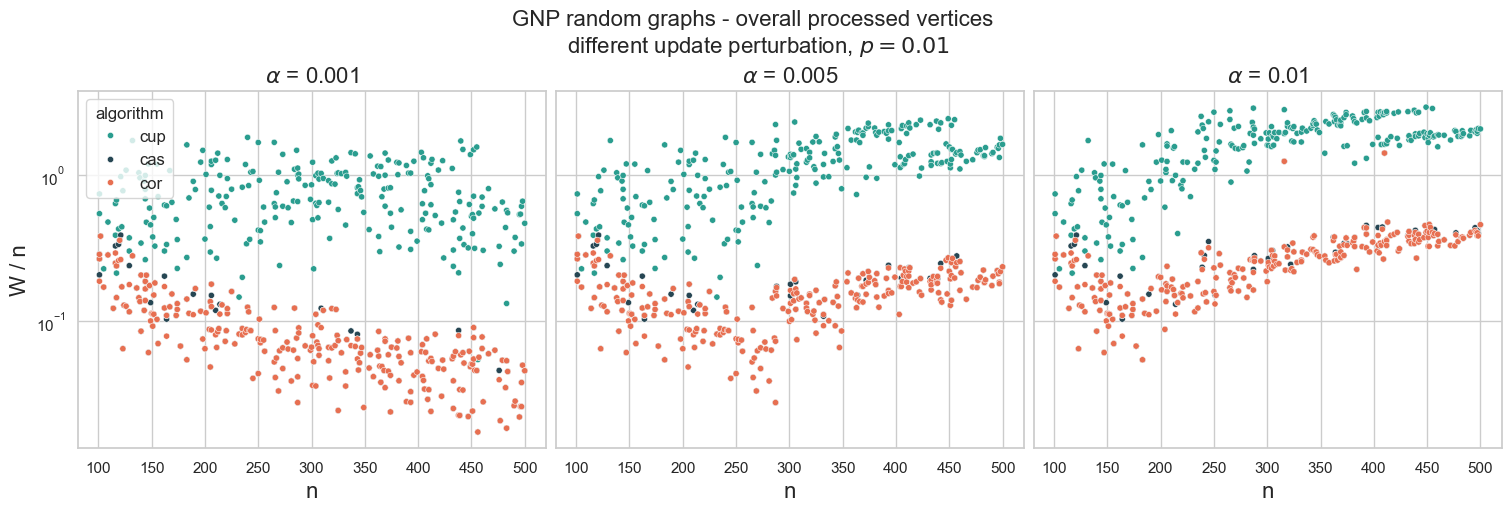

In [78]:
# all alpha vs p = 0.01 - log!
results = [all_results["p_1"][a] for a in a_list]
sns.set_theme(context="notebook", style="whitegrid")
palette = {
    "cas": "#264653",  # deep blue-green
    "cor": "#E76F51",  # coral
    "cup": "#2A9D8F"   # teal
}



fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    sharey=True,
    figsize=(15, 5),
    constrained_layout=True
)
for k in range(3):
    ax = axes[k]
    a = [0.001, 0.005, 0.01][k]
    df_long = df_categorical(results[k], "W")
    df_long["W_norm"] = df_long["W"] /df_long["n"]
    sns.scatterplot(data=df_long, 
                    x="n", 
                    y="W_norm", 
                    hue="algorithm", 
                    palette=palette, 
                    ax=ax,
                    s=20)

    ax.set_title(fr"$\alpha$ = {a}", fontsize=16)
    ax.set_xlabel("n", fontsize=16)
    ax.set_ylabel("W / n", fontsize=16)
    #ax.set_ylim(0,1200)
    ax.set_yscale("log")  
    ax.legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, title="algorithm", fontsize=12, loc="upper left")

fig.suptitle(f"GNP random graphs - overall processed vertices \n different update perturbation, " + r"$p = 0.01$", fontsize=16)
plt.savefig(base_plots / "random_graphs" / "W_norm_vs_alpha_log.png", dpi=300)
plt.show()

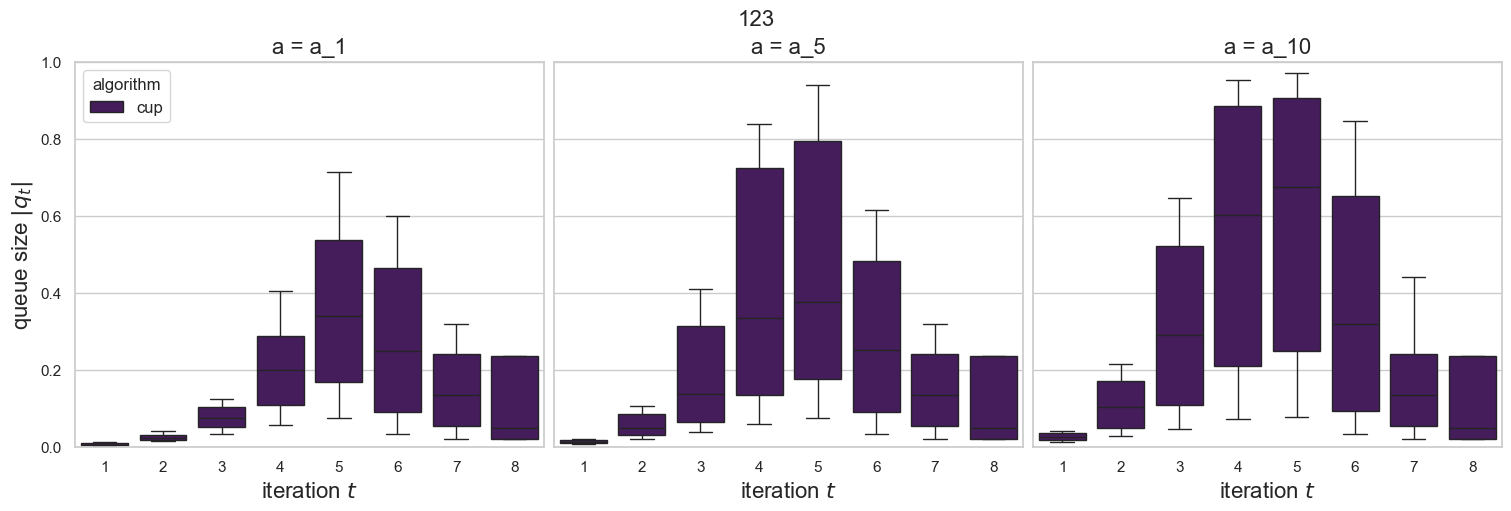

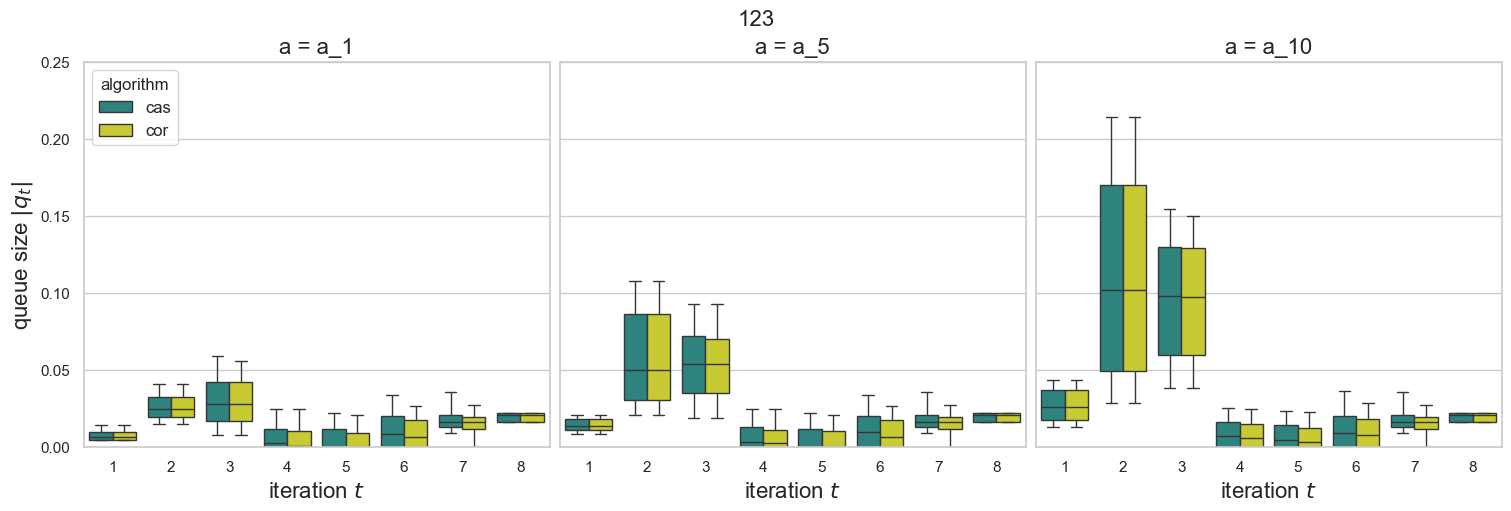

In [17]:
# Queue length in each iteration, fixed p = 0.01, all alpha

sns.set_theme(context="notebook", style="whitegrid")
palette = [cmap(i) for i in [0.05, 0.5, 0.95]]
a_list = ["a_1", "a_5", "a_10"]
results = [all_results["p_1"][a] for a in a_list]       

# --- helpers (same idea as before) ---
def explode_q_lens(df_long, col="q_lens"):
    d = df_long.copy()
    d[col] = d[col].apply(lambda x: x if isinstance(x, (list, tuple, np.ndarray)) else [])
    d = d.explode(col, ignore_index=True).rename(columns={col: "q_len"})
    group_cols = [c for c in d.columns if c not in ["q_len"]]
    d["iter"] = d.groupby(group_cols).cumcount() + 1
    d["q_len"] = pd.to_numeric(d["q_len"], errors="coerce")
    return d.dropna(subset=["q_len"])


# prepare results per alpha


# build two figures: (CAS,COR) and (CUP)
splits = [
    (["cup"],        "Queue length per iteration (CUP)", [palette[0]], (0, 1)),
    (["cas", "cor"], "Queue length per iteration (CAS/COR)", [palette[1], palette[2]], (0, 0.25)),
]

figs = []
for alg_subset, fig_title, pal, ylim in splits:
    fig, axes = plt.subplots(
        nrows=1, 
        ncols=len(a_list), 
        sharey=True,
        figsize=(15, 5), 
        constrained_layout=True
    )
    
    for k, a in enumerate(a_list):
        ax = axes[k]

        df_long = df_categorical(results[k], "q_lens")   # your function
        df_it = explode_q_lens(df_long, col="q_lens")
        df_it["q_frac"] = df_it["q_len"] / df_it["n"]

        df_it = df_it[df_it["algorithm"].isin(alg_subset)]

        sns.boxplot(
            data=df_it,
            x="iter",
            y="q_frac",
            hue="algorithm",
            showfliers=False,
            whis=(10, 90),
            palette=pal,
            ax=ax
        )

        ax.set_title(f"a = {a}", fontsize=16)
        ax.set_xlabel("iteration $t$", fontsize=16)
        ax.set_ylabel(r"queue size $|q_t|$", fontsize=16)
        ax.set_ylim(*ylim)

        if ax.legend_ is not None:
            ax.legend_.remove()

    # single legend per figure
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels, title="algorithm", fontsize=12, loc="upper left")

    fig.suptitle(f"123", fontsize=16)
    figs.append(fig)


plt.show()

C:\Users\korol\AppData\Local\Temp\ipykernel_21556\117613487.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(run_cols + ["bin4"], as_index=False)["q_frac"]
C:\Users\korol\AppData\Local\Temp\ipykernel_21556\117613487.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(run_cols + ["bin4"], as_index=False)["q_frac"]
C:\Users\korol\AppData\Local\Temp\ipykernel_21556\117613487.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default a

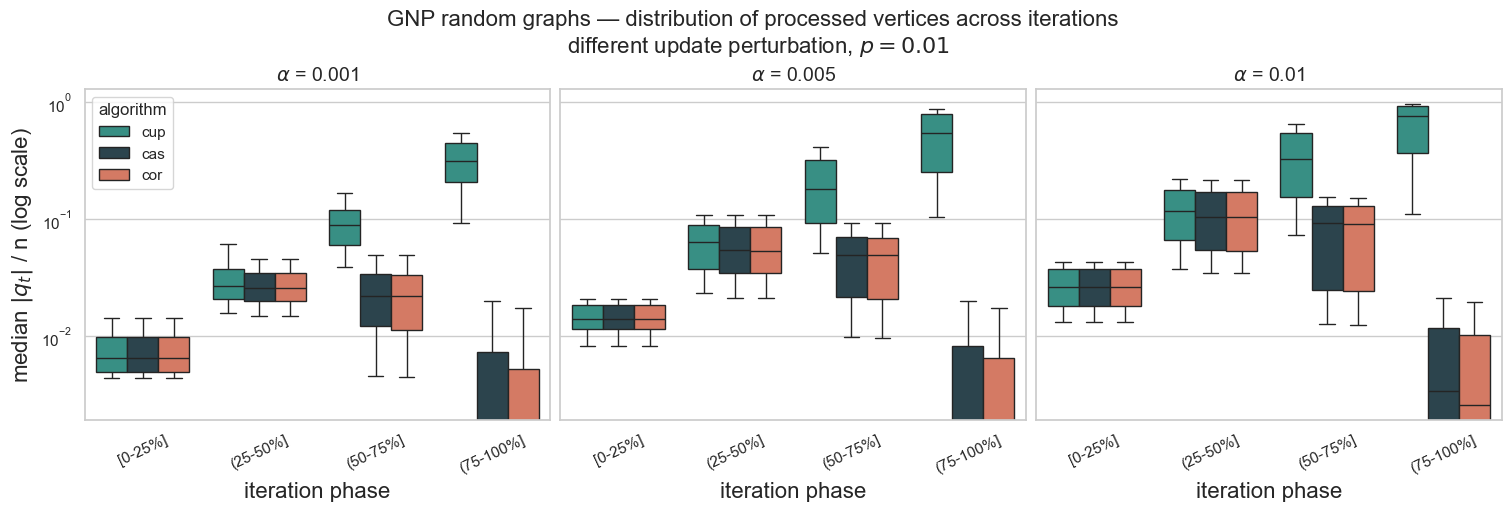

In [79]:
sns.set_theme(context="notebook", style="whitegrid")

a_list   = ["a_1", "a_5", "a_10"]
results  = [all_results["p_1"][a] for a in a_list]
palette = {
    "cas": "#264653",  # deep blue-green
    "cor": "#E76F51",  # coral
    "cup": "#2A9D8F"   # teal
}


# ---------- helpers ----------
def explode_q_lens(df_long, col="q_lens"):
    d = df_long.copy()
    d[col] = d[col].apply(lambda x: x if isinstance(x, (list, tuple, np.ndarray)) else [])
    d = d.explode(col, ignore_index=True).rename(columns={col: "q_len"})
    group_cols = [c for c in d.columns if c not in ["q_len"]]
    d["iter"] = d.groupby(group_cols).cumcount() + 1
    d["q_len"] = pd.to_numeric(d["q_len"], errors="coerce")
    return d.dropna(subset=["q_len"])

def add_rel_bin(df_it, n_bins=4, bin_col="bin4"):
    # identify "run" columns (everything except the iteration-level fields)
    run_cols = [c for c in df_it.columns if c not in ["q_len", "iter", "q_frac", bin_col]]

    # per-run T and relative position r in (0,1]
    T = df_it.groupby(run_cols)["iter"].transform("max").astype(float)
    r = df_it["iter"] / T

    edges  = np.linspace(0, 1, n_bins + 1)
    labels = ["[0-25%]", "(25-50%]", "(50-75%]", "(75-100%]"]
    df_it[bin_col] = pd.cut(r, bins=edges, labels=labels, include_lowest=False, right=True)
    df_it[bin_col] = pd.Categorical(df_it[bin_col], categories=labels, ordered=True)
    return df_it, run_cols, labels

# ---------- build + plot ----------
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(a_list),
    sharey=True,
    figsize=(15, 5),
    constrained_layout=True
)

for k, a in enumerate(a_list):
    ax = axes[k]

    df_long = df_categorical(results[k], "q_lens")    # your existing function
    df_it   = explode_q_lens(df_long, col="q_lens")

    # normalize queue size
    df_it["q_frac"] = df_it["q_len"] / df_it["n"]

    # bin by relative iteration position (4 bins)
    df_it, run_cols, bin_order = add_rel_bin(df_it, n_bins=4, bin_col="bin4")

    # ROBUST summary: median per run x bin (instead of mean)
    df_bin = (df_it
            .groupby(run_cols + ["bin4"], as_index=False)["q_frac"]
            .median()
            .rename(columns={"q_frac": "q_frac_median"}))

    # Plot: boxplot (no violins), suppress outliers, 10–90 whiskers
    sns.boxplot(
        data=df_bin,
        x="bin4",
        y="q_frac_median",
        hue="algorithm",
        hue_order=["cup", "cas", "cor"],
        order=bin_order,
        showfliers=False,
        whis=(10, 90),
        palette=palette,
        ax=ax
    )

    ax.set_title(rf"$\alpha$ = {[0.001, 0.005, 0.01][k]}", fontsize=14)
    ax.set_xlabel("iteration phase", fontsize=16)
    ax.set_ylabel(r"median $|q_t|$ / n (log scale)", fontsize=16)
    ax.tick_params(axis="x", rotation=25)
    ax.set_yscale("log")

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes[1:]:
    ax.legend_.remove()

axes[0].legend(handles, labels, title="algorithm", loc="upper left")

fig.suptitle(f"GNP random graphs — distribution of processed vertices across iterations \n different update perturbation, " + r"$p = 0.01$", fontsize=16)
plt.savefig(base_plots / "random_graphs" / "q_distribution_log.png", dpi=300)
plt.show()


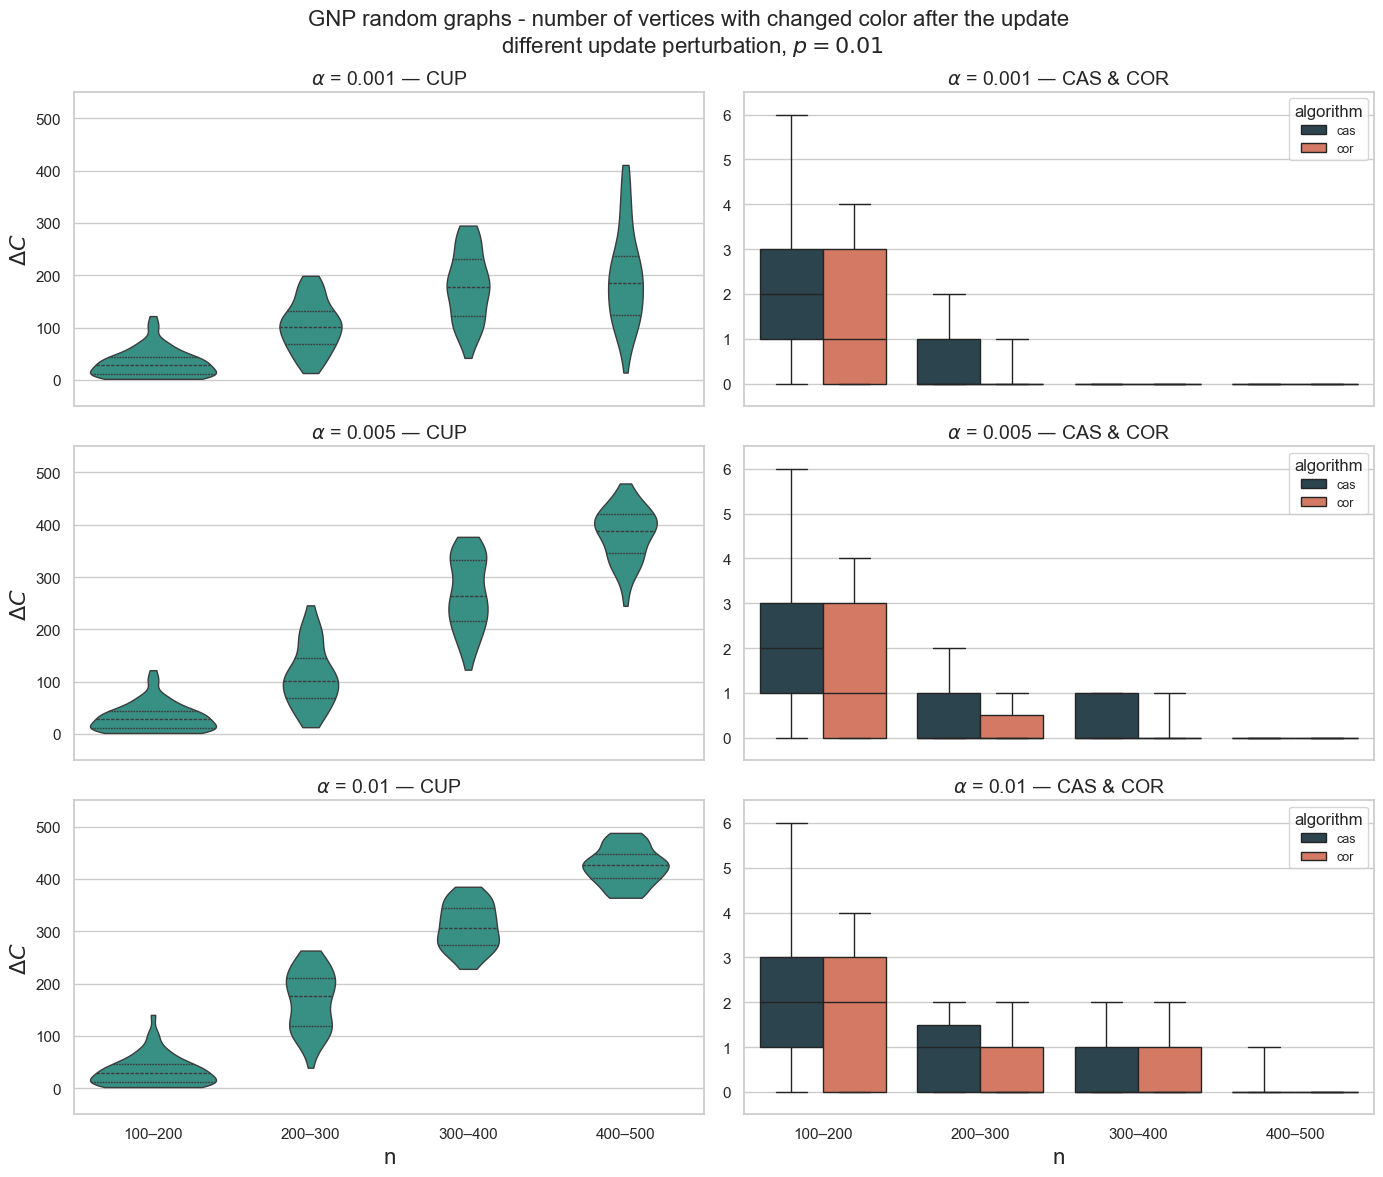

In [99]:
sns.set_theme(context="notebook", style="whitegrid")

a_list   = ["a_1", "a_5", "a_10"]
results  = [all_results["p_1"][a] for a in a_list]
palette = {
    "cas": "#264653",  # deep blue-green
    "cor": "#E76F51",  # coral
    "cup": "#2A9D8F"   # teal
}

fig, axes = plt.subplots(
    nrows=len(a_list),
    ncols=2,
    figsize=(14, 12),
    sharex=True
)

for i, a in enumerate([0.001, 0.005, 0.01]):

    df = df_categorical(results[i], "v_changed") 
    bins = [100, 200, 300, 400, 500] 
    labels = ["100–200", "200–300", "300–400", "400–500"] 
    df["n_bin"] = pd.cut(df["n"], bins=bins, labels=labels, include_lowest=True)
    
    # ---- CUP (left column) ----
    df_cup = df[df["algorithm"] == "cup"]

    sns.violinplot(
        data=df_cup,
        x="n_bin",
        y="v_changed",
        hue="algorithm",
        hue_order=["cup"],
        palette={"cup": palette["cup"]},
        cut=0,
        inner="quartile",
        linewidth=1,
        ax=axes[i, 0]
    )

    axes[i, 0].set_title(rf"$\alpha$ = {a} — CUP", fontsize=14)
    axes[i, 0].set_ylabel(r"$\Delta C$", fontsize=16)
    axes[i, 0].legend_.remove()
    axes[i, 0].set_ylim(-50,550)


    # ---- CAS + COR (right column) ----
    df_pruned = df[df["algorithm"].isin(["cas", "cor"])]

    sns.boxplot(
        data=df_pruned,
        x="n_bin",
        y="v_changed",
        hue="algorithm",
        hue_order=["cas", "cor"],
        palette={"cas": palette["cas"], "cor": palette["cor"]},
        linewidth=1,
        dodge=True,
        ax=axes[i, 1],
        whis=(10, 90),
        showfliers=False,
    )

    axes[i, 1].set_title(rf"$\alpha$ = {a} — CAS & COR", fontsize=14)
    axes[i, 1].set_ylabel("")
    axes[i, 1].legend(title="algorithm", fontsize=9)
    axes[i, 1].set_ylim(-0.5, 6.5)

axes[2, 0].set_xlabel("n", fontsize=16)
axes[2, 1].set_xlabel("n", fontsize=16)
fig.suptitle(f"GNP random graphs - number of vertices with changed color after the update \n"
            f"different update perturbation, " + r"$p = 0.01$", fontsize=16)
plt.savefig(base_plots / "random_graphs" / "C_delta_vs_alpha.png", dpi=300)

plt.tight_layout()
plt.show()


In [106]:
# Summary table: c_delta, t_delta

order = ["cup", "cas", "cor"]
a_list   = ["a_1", "a_5", "a_10"]
results  = [all_results["p_1"][a] for a in a_list]
for i in [0,1,2]:
    print(f"\n {a_list[i]}")
    dfC = df_categorical(results[i], "v_changed")
    dfT = df_categorical(results[i], "T_delta")

    df = dfC.merge(dfT, on=["graph_id","n","algorithm"], how="inner", validate="one_to_one")

    df["c_delta"] = df["v_changed"]
    df["algorithm"] = pd.Categorical(df["algorithm"], categories=order, ordered=True)

    desc_c = (df.groupby("algorithm")["c_delta"]
                .describe(percentiles=[0.25, 0.5, 0.75])
                .rename(columns={"50%": "median"}))

    p_pos_c = (df.groupby("algorithm")["c_delta"]
                .apply(lambda s: (s > 0).mean())
                .rename("p(c_delta>0)"))

    tab_c = desc_c.join(p_pos_c).loc[order]
    print(tab_c)

    # Same idea for T_delta, plus p(T_delta != 0)
    desc_T = (df.groupby("algorithm")["T_delta"]
                .describe(percentiles=[0.25, 0.5, 0.75])
                .rename(columns={"50%": "median"}))

    p_nonzero_T = (df.groupby("algorithm")["T_delta"]
                    .apply(lambda s: (s != 0).mean())
                    .rename("p(T_delta!=0)"))

    tab_T = desc_T.join(p_nonzero_T).loc[order]
    print(tab_T)

    # Optional: LaTeX export
    tab_c.to_latex(base_plots / "random_graphs" / f"table_c_delta_{a_list[i]}.tex", float_format="%.4g")
    tab_T.to_latex(base_plots / "random_graphs" / f"table_T_delta_{a_list[i]}.tex", float_format="%.4g")


 a_1
           count     mean        std  min    25%  median    75%    max  \
algorithm                                                                
cup        250.0  129.968  91.084403  2.0  50.75   118.5  186.0  411.0   
cas        250.0    0.908   3.278801  0.0   0.00     0.0    1.0   47.0   
cor        250.0    0.752   3.201797  0.0   0.00     0.0    1.0   47.0   

           p(c_delta>0)  
algorithm                
cup               1.000  
cas               0.300  
cor               0.264  
           count   mean       std  min  25%  median  75%  max  p(T_delta!=0)
algorithm                                                                   
cup        250.0  0.028  0.208302 -1.0  0.0     0.0  0.0  2.0          0.032
cas        250.0  1.108  0.850429  0.0  0.0     1.0  2.0  3.0          0.716
cor        250.0  1.168  0.838204  0.0  1.0     1.0  2.0  3.0          0.752

 a_5
           count     mean         std  min    25%  median    75%    max  \
algorithm                  

C:\Users\korol\AppData\Local\Temp\ipykernel_21556\4241924820.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc_c = (df.groupby("algorithm")["c_delta"]
C:\Users\korol\AppData\Local\Temp\ipykernel_21556\4241924820.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p_pos_c = (df.groupby("algorithm")["c_delta"]
C:\Users\korol\AppData\Local\Temp\ipykernel_21556\4241924820.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this wa

In [116]:
# Symmetry in graphs:

# Expected: one row per graph instance
# Columns: n, sym_old, sym_up, unique_old, unique_up (counts)
# If they are already fractions, skip the "/ n" normalization below.

a_list  = ["a_1", "a_5", "a_10"]
results = [all_results["p_1"][a]["cor"] for a in a_list]   # list aligned with a_list

def mean_pm_std(s: pd.Series) -> str:
    return f"{s.mean():.6f} ± {s.std():.6f}"

rows = []

for a, dfg in zip(a_list, results):
    dfg = dfg.copy()

    # normalize to fractions
    for c in ["sym_old", "sym_up", "unique_old", "unique_up"]:
        dfg[c + "_frac"] = dfg[c] / dfg["n"]

    rows.append({
        "dataset": f"p=0.01, {a}",
        "runs": len(dfg),
        "sym_old/n": mean_pm_std(dfg["sym_old_frac"]),
        "sym_up/n": mean_pm_std(dfg["sym_up_frac"]),
        "unique_old/n": mean_pm_std(dfg["unique_old_frac"]),
        "unique_up/n": mean_pm_std(dfg["unique_up_frac"]),
        "Δsym_frac": f"{(dfg['sym_up_frac'] - dfg['sym_old_frac']).mean():.3f}",
        "Δunique_frac": f"{(dfg['unique_up_frac'] - dfg['unique_old_frac']).mean():.3f}",
    })

out = pd.DataFrame(rows)

print(out)

out.to_latex(
    base_plots / "random_graphs" / "dataset_symmetry_summary_p_1_by_a.tex",
    index=False,
    escape=False
)

        dataset  runs            sym_old/n             sym_up/n  \
0   p=0.01, a_1   250  0.173380 ± 0.206838  0.169275 ± 0.199644   
1   p=0.01, a_5   250  0.173380 ± 0.206838  0.169167 ± 0.199687   
2  p=0.01, a_10   250  0.173380 ± 0.206838  0.168919 ± 0.199737   

          unique_old/n          unique_up/n Δsym_frac Δunique_frac  
0  0.858058 ± 0.172839  0.861323 ± 0.167146    -0.004        0.003  
1  0.858058 ± 0.172839  0.861344 ± 0.167151    -0.004        0.003  
2  0.858058 ± 0.172839  0.861424 ± 0.167164    -0.004        0.003  


## Describe the dataset
- random graphs: gnp_random_graph (Erdős-Rényi)
- we investigate sparse graphs: p=0.05, 0.01 and compare with 0.05
- in each we change 0.001, 0.005, 0.01 existing edges 
- show how many edges is it
- what is the queue
- % of cases (in all graphs?) where cup/cas/cor needed less iterations
- q_len: doesnt make sense in highly asymmetric graphs!


\begin{enumerate}
    \item how many vertices change color after the whole change in the graph
    \item changing n, changing S
    \item How many vertices were recolored during the whole process
    \item average queue size
    \item some cool big graph were we change e.g. 1 edge, 1\% of edges, 5\%, 10\%
\end{enumerate}

In [115]:
for a, df in zip(a_list, results):
    print(a, df.get("a", pd.Series(["<no a col>"])).unique()[:5])




a_1 ['<no a col>']
a_5 ['<no a col>']
a_10 ['<no a col>']
